### Load Modules

In [359]:
import functools
from functools import reduce
from pathlib import Path
import itertools
import math
from typing import Sequence, Callable, Iterable, List, Tuple, Dict
from itertools import product
from dataclasses import dataclass
from tqdm import tqdm
import warnings
import pickle
warnings.filterwarnings("ignore")

import scanpy as sc
from anndata import AnnData
import numpy as np
from numpy.typing import NDArray
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import non_negative_factorization
import matplotlib.pyplot as plt
import scipy
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import cosine
from sklearn.metrics import mean_squared_error

from disk_cache import disk_cache

### Utilties

In [391]:
def tuple_to_dataclass(func, dataclass_type):
    """Wraps a function that returns a tuple and converts it to a dataclass instance."""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        return dataclass_type(*func(*args, **kwargs))
    return wrapper

def plot_bar_box_celltype_dict(results, n_components_range):
    num_celltypes = len(results)
    grid_size = math.ceil(math.sqrt(num_celltypes))  
    
    fig, axes = plt.subplots(nrows=grid_size, ncols=grid_size, 
                             figsize=(5 * grid_size, 5 * grid_size), 
                             sharey=True)
    
    axes = np.array(axes).flatten()
    
    for ax, (celltype, results) in zip(axes, results.items()):
        x_positions = np.arange(len(n_components_range)) + 1
    
        boxprops = dict(facecolor="none", edgecolor="black", linewidth=1.5)
        medianprops = dict(color="black", linewidth=1.5)
        whiskerprops = dict(color="black", linewidth=1)
        capprops = dict(color="black", linewidth=1)
    
        ax.boxplot(results["box_values"], positions=x_positions,
                   patch_artist=True,
                   boxprops=boxprops, medianprops=medianprops,
                   whiskerprops=whiskerprops, capprops=capprops)
    
        ax.plot(x_positions, results["bar_values"], color="skyblue")
    
        ax.set_xlabel("n_components")
        ax.set_xticks(x_positions)
        ax.set_xticklabels(n_components_range, ha="right")
        ax.set_title(f"Pearson Correlation\n{celltype}")
    
        ax.set_ylim(0, 1)
    
    for i in range(num_celltypes, len(axes)):
        fig.delaxes(axes[i])
    
    fig.supylabel("Pearson Correlation", fontsize=12)
    fig.suptitle("NMF Correlation Analysis Across Cell Types", fontsize=14)
    
    plt.tight_layout()
    plt.show()

def convert_to_float64_array(mtx):
    if isinstance(mtx, scipy.sparse.spmatrix):
        mtx = mtx.toarray().copy()
    if isinstance(mtx, np.ndarray):
        mtx = mtx.astype(np.float64).copy()
    return mtx

def adata_X_to_ndarray(X) -> NDArray:
    if X is None:
        raise ValueError("adata.X is None")
    if scipy.sparse.issparse(X):
        return X.toarray()
    if isinstance(X, np.ma.MaskedArray):
        return X.filled(0)
    try:
        import h5py
        if isinstance(X, h5py.Dataset):
            return X[:]
    except ImportError:
        pass
    if hasattr(X, "__getitem__") and hasattr(X, "shape"):
        try:
            return np.array(X[:]) 
        except Exception:
            pass
    if isinstance(X, np.ndarray):
        return X
    return np.array(X)

def return_multiindex_from_func(
    iterator: Iterable, 
    func: Callable, 
    index_names: Tuple
) -> pd.Series:
    """
    Apply a function to each element of an iterable and return a pandas Series 
    with a MultiIndex created from the iterable's elements.

    Parameters:
    - iterator (Iterable): An iterable of tuples to create the MultiIndex.
    - func (Callable): A function to apply to each tuple in the iterator.
    - index_names (Tuple): Names for the MultiIndex levels.

    Returns:
    - pd.Series: A pandas Series with a MultiIndex and values resulting from 
                  applying the function to the iterable.
    """
    iterator_list = list(iterator)
    values = [func(*args) for args in iterator_list]
    multiindex = pd.MultiIndex.from_tuples(iterator_list, names=index_names)
    return pd.Series(values, index=multiindex)

def apply_funcs_to_Series(
    Series: pd.Series,
    metric_functions: Dict[str, Callable]
) -> pd.DataFrame:
    dfs = [Series.map(func).to_frame() for func in metric_functions.values()]
    df = reduce(lambda a, b: pd.merge(a, b, left_index=True, right_index=True), dfs)
    df.columns = list(metric_functions.keys())
    return df

def plot_celltype_metrics(df: pd.DataFrame, n_cols: int=3, dpi: int=100):
    """
    Plots MSE and Explained Variance for each celltype in a grid of subplots, 
    with each celltype having its own plot and two y-axes.

    Parameters:
    df (pd.DataFrame): A DataFrame with MultiIndex ('celltype', 'n_components') and columns 'MSE' and 'Explained Variance'.
    """
    celltypes = df.index.get_level_values('celltype').unique()
    n_celltypes = len(celltypes)
    n_rows = int(np.ceil(n_celltypes / n_cols))  

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4), dpi=dpi)

    axes = axes.flatten()

    for i, celltype in enumerate(celltypes):
        ax = axes[i]
        
        celltype_data = df.loc[celltype]
        
        ax.plot(celltype_data.index, celltype_data['MSE'], marker='o', color='tab:blue')
        
        ax2 = ax.twinx()
        ax2.plot(celltype_data.index, celltype_data['Explained Variance'], marker='o', color='tab:orange')
        
        ax.set_title(f"Celltype: {celltype}")
        ax.set_xlabel('Number of Components')
        ax.set_ylabel('MSE', color='tab:blue')
        ax2.set_ylabel('Explained Variance', color='tab:orange')
        
        ax.legend(loc='upper left')
        ax2.legend(loc='upper right')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

### Method

In [45]:
@dataclass
class NMF_Result:
    W: np.ndarray
    H: np.ndarray
    n_iter: int | None

@dataclass
class NMF_Transfer_Result:
    nmf_result_init: NMF_Result
    nmf_result_final: NMF_Result

def bootstrap_adata(
        adata: sc.AnnData
) -> sc.AnnData:
    """Returns a bootstrapped adata object by sampling with replacement along the obs/cells"""
    return adata[np.random.choice(adata.n_obs, adata.n_obs)].copy()

# to make filtering less tedious
filter_by_obs_value = lambda adata, obs_column, obs_value: adata[adata.obs[obs_column] == obs_value].copy()

# Wrapping sklearn's NMF function to return a dataclass instead of a tuple
non_negative_factorization_wrapped = tuple_to_dataclass(non_negative_factorization, NMF_Result)

def nmf_transfer(
    adata_query: sc.AnnData, 
    adata_reference: sc.AnnData, 
    n_components: int | float,
    shared_genes: Sequence[str] | pd.Index
) -> NMF_Transfer_Result:
    """
    Perform Non-negative Matrix Factorization (NMF) on both a query and reference AnnData object 
    using shared genes, and transfer the factorization from the reference to the query.

    This function first performs NMF on the reference data and then applies the learned (gene) components 
    to the query data. Specifically, the H matrix (gene by components) learned from the reference is used to initialize 
    the factorization for the query, with the option to freeze the H matrix (i.e., not update it 
    during the optimization process).

    Parameters:
    -----------
    adata_query : sc.AnnData
        The AnnData object representing the query dataset on which NMF will be applied.
    
    adata_reference : sc.AnnData
        The AnnData object representing the reference dataset from which the NMF components (W, H) 
        will be learned.

    n_components : int | float
        The number of components to factorize the data into. Whole numbers only.

    shared_genes : Sequence[str] | pd.Index
        A sequence of gene names (or an Index) shared between the query and reference datasets. These 
        shared genes are used to align both datasets for NMF.

    Returns:
    --------
    NMF_Transfer_Result
        A dataclass containing the results of the NMF process on both the reference and query data. 
        It includes:
        - `nmf_result_init`: The result of the NMF on the reference dataset.
        - `nmf_result_final`: The result of the NMF on the query dataset with the reference H matrix applied.
    """

    indexer_query, indexer_reference = tuple(map(
        lambda adata: adata.var_names.get_indexer_for(shared_genes), 
        (adata_query, adata_reference)
    ))
    nmf_result_init = non_negative_factorization_wrapped(adata_reference[:, indexer_reference].X, n_components=n_components)
    nmf_result_final = non_negative_factorization_wrapped(adata_query[:, indexer_query].X, H=nmf_result_init.H, init="custom", update_H=False)
    return NMF_Transfer_Result(nmf_result_init, nmf_result_final)

def nmf_count_reconstruction(
    adata_query: sc.AnnData, 
    adata_reference: sc.AnnData, 
    n_components: int | float,
    shared_genes: Sequence[str] | pd.Index,
) -> np.ndarray:
    """
    Reconstructs the gene expression matrix for a query dataset using Non-negative Matrix Factorization (NMF) 
    components learned from a reference dataset.

    This function performs the following steps:
    1. Computes the NMF factorization of the reference dataset (`adata_reference`) using the shared genes.
    2. Iterates over each shared gene and reconstructs its expression in the query dataset by:
       - Excluding the current gene from the factorization process.
       - Using the learned W matrix from the query dataset and the H matrix from the reference dataset.
       - Predicting the expression of the excluded gene using matrix multiplication.

    Parameters:
    -----------
    adata_query : sc.AnnData
        The AnnData object representing the query dataset for which the gene expression matrix is to be reconstructed.
    
    adata_reference : sc.AnnData
        The AnnData object representing the reference dataset from which the NMF components (W, H) 
        will be learned and transferred to the query dataset.

    n_components : int | float
        The number of components to factorize the data into. This is a whole number representing 
        the number of latent components.

    shared_genes : Sequence[str] | pd.Index
        A sequence of gene names (or an Index) shared between the query and reference datasets. These 
        shared genes are used to align both datasets for NMF.

    Returns:
    --------
    np.ndarray
        The reconstructed gene expression matrix for the query dataset. This matrix has shape 
        `(n_cells_query, n_shared_genes)`, where each column corresponds to the predicted expression 
        levels of a specific gene across all cells in the query dataset.

    Notes:
    ------
    - The function assumes that all genes in `shared_genes` exist in both the query and reference datasets.
    - Each gene is reconstructed by performing NMF with all other shared genes, and the missing gene 
      is inferred from the learned factors.
    - The final reconstructed expression matrix is built by horizontally stacking the predictions for each gene.
    """
    indexer_query, indexer_reference = tuple(map(
        lambda adata: adata.var_names.get_indexer_for(shared_genes), 
        (adata_query, adata_reference)
    ))
    nmf_result_init = non_negative_factorization_wrapped(adata_reference[:, indexer_reference].X, n_components=n_components)
    count_reconstruction = []
    for gene in shared_genes:
        gene_mask = ~np.isin(shared_genes, gene)
        nmf_result_gene = non_negative_factorization_wrapped(adata_query[:, indexer_query][:, gene_mask].X, H=nmf_result_init.H[:, gene_mask], init="custom", update_H=False)
        count_reconstruction.append(nmf_result_gene.W @ nmf_result_init.H[:, ~gene_mask])
    return np.hstack(count_reconstruction)

reconstruct_from_nmf_res = lambda nmf_res: nmf_res.W @ nmf_res.H
# Function to make it easier to return a reconstructed matrix from the W and H matrices stored in an object NMF_Transfer_Result
reconstruct_from_nmf_transfer_res = lambda nmf_transfer_result: nmf_transfer_result.nmf_result_final.W @ nmf_transfer_result.nmf_result_init.H

def pearsonr_nmf_transfer(
    adata_query: sc.AnnData,
    adata_reference: sc.AnnData,
    n_components: float | int,
    shared_genes: Sequence[str] | pd.Index
):
    """
    Computes the Pearson correlation coefficient between the reconstructed and observed gene expression 
    for a query dataset after performing Non-negative Matrix Factorization (NMF) transfer from a reference dataset.
    
    This function performs the following:
    1. Transfers NMF components from the reference dataset (`adata_reference`) to the query dataset (`adata_query`) 
       by using the learned (gene) components from the reference.
    2. Calculates the predicted gene expression in the query dataset using the learned components.
    3. Computes the Pearson correlation between the mean expression of the shared genes in the query dataset 
       and the reconstructed expression for the same genes.
    
    Parameters:
    -----------
    adata_query : sc.AnnData
        The AnnData object representing the query dataset on which gene expression is to be predicted.
        
    adata_reference : sc.AnnData
        The AnnData object representing the reference dataset from which the NMF components (W, H) 
        will be learned and transferred to the query dataset.
    
    n_components : int | float
        The number of components to factorize the data into. Whole numbers only.
    
    shared_genes : Sequence[str] | pd.Index
        A sequence of gene names (or an Index) shared between the query and reference datasets for alignment.
    
    Returns:
    --------
    float
        The Pearson correlation coefficient between the observed and predicted gene expression for the shared genes in the query dataset.
    
    Notes:
    ------
    - This function uses the `nmf_transfer` function to transfer the NMF components from the reference to the query dataset.
    - The Pearson correlation is computed on the mean expression of the shared genes across cells in the query dataset.
    - The function assumes that the shared genes exist in both `adata_query` and `adata_reference`.
    """
    reconstruction = (lambda nmf_transfer_result: nmf_transfer_result.nmf_result_final.W @ nmf_transfer_result.nmf_result_init.H)(
        nmf_transfer(
            adata_query, 
            adata_reference, 
            n_components, 
            shared_genes)
    )
    return float(pearsonr(
        adata_query[:, shared_genes].X.mean(axis=0),
        reconstruction.mean(axis=0)
    )[0])

def pearsonr_nmf_reconstruction(
    adata_query: sc.AnnData,
    adata_reference: sc.AnnData,
    n_components: float | int,
    shared_genes: Sequence[str] | pd.Index
):
    """
    Computes the Pearson correlation coefficient between the observed and predicted gene expression 
    for a query dataset using Non-negative Matrix Factorization (NMF)-based reconstruction from the reference dataset.
    
    This function performs the following:
    1. Performs NMF-based reconstruction of gene expression in the query dataset (`adata_query`) 
       using the shared genes from the reference dataset (`adata_reference`).
    2. Computes the Pearson correlation between the observed gene expression in the query dataset 
       and the reconstructed expression for the same genes.
    
    Parameters:
    -----------
    adata_query : sc.AnnData
        The AnnData object representing the query dataset for which the gene expression is predicted.
    
    adata_reference : sc.AnnData
        The AnnData object representing the reference dataset from which the NMF components (W, H) 
        will be learned and transferred to the query dataset.
    
    n_components : int | float
        The number of components to use for the NMF factorization.
    
    shared_genes : Sequence[str] | pd.Index
        A sequence of gene names (or an Index) shared between the query and reference datasets for alignment.
    
    Returns:
    --------
    float
        The Pearson correlation coefficient between the observed and reconstructed gene expression for the shared genes in the query dataset.
    
    Notes:
    ------
    - This function uses the `nmf_count_reconstruction` function to perform NMF-based reconstruction on the query dataset.
    - Pearson correlation is computed on the mean expression of the shared genes across cells in the query dataset.
    - The function assumes that the shared genes exist in both `adata_query` and `adata_reference`.
    """
    reconstruction = nmf_count_reconstruction(
        adata_query,
        adata_reference, 
        n_components, 
        shared_genes
    )
    #return float(pearsonr(
    #    np.log(adata_query[:, shared_genes].X.mean(axis=0) + 1e-3),
    #    np.log(reconstruction.mean(axis=0) + 1e-3)
    #)[0])
    #return float(pearsonr(
    #    adata_query[:, shared_genes].X.mean(axis=0),
    #    reconstruction.mean(axis=0),
    #)[0])
    #return float(spearmanr(
    #    adata_query[:, shared_genes].X.mean(axis=0),
    #    reconstruction.mean(axis=0),
    #)[0])
    #return float(cosine(
    #    adata_query[:, shared_genes].X.mean(axis=0),
    #    reconstruction.mean(axis=0),
    #))
    return float(cosine(
        np.log(adata_query[:, shared_genes].X.mean(axis=0) + 1e-3),
        np.log(reconstruction.mean(axis=0) + 1e-3)
    ))


### Load Data

#### Farah et al data

In [ ]:
adata_sc = sc.read_h5ad(Path.cwd() / "data" / "farah_et_al" / "inputRef" / "overall_heart.h5ad")
adata_sp = (lambda adata, obs_column: adata[adata.obs[obs_column] == adata.obs[obs_column].unique()[0]])(
    sc.read_h5ad(Path.cwd() / "data" / "farah_et_al" / "inputQuery" / "overall_merfish.h5ad"),
    "sample_id"
)
adata_sp_obs = sc.read_h5ad(Path.cwd() / "data" / "farah_et_al" / "nico_out" / "nico_celltype_annotation.h5ad").obs
adata_sp.obs = adata_sp.obs.join(adata_sp_obs)

sc.pp.filter_genes(adata_sp, min_counts=20)
sc.pp.filter_cells(adata_sp, min_genes=10)
sc.pp.filter_genes(adata_sc, min_counts=20)
sc.pp.filter_cells(adata_sc, min_genes=10)

shared_genes_mask_sc = np.isin(adata_sc.var_names, adata_sp.var_names)
shared_genes_mask_sp = np.isin(adata_sp.var_names, adata_sc.var_names)
shared_genes = adata_sc[:, shared_genes_mask_sc].var_names

print(f"{len(shared_genes)=}")

adata_sc.obs["celltype"] = adata_sc.obs["major_cell_class"]
adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
celltypes = list(set.intersection(set(adata_sp.obs["celltype"]), set(adata_sc.obs["celltype"])))
print(f"{adata_sc=}\n{adata_sp=}")


FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '/Users/egerc/Documents/Projects/spatial_transcript_inference/data/farah_et_al/inputRef/overall_heart.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
# adata_query and adata_reference need to have the same dtype
adata_sc.X = adata_sc.X.toarray()
adata_sp.X = adata_sp.X.astype(np.float64)

In [ ]:
# Reducing size of data
adata_sc = adata_sc[np.random.choice(adata_sc.n_obs, 2500, replace=False)]
adata_sp = adata_sp[np.random.choice(adata_sp.n_obs, 8000, replace=False)]
print(f"{adata_sc=}\n{adata_sp=}")

adata_sc=View of AnnData object with n_obs × n_vars = 2500 × 22174
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'Rep', 'Age', 'Region', 'RNA_snn_res.0.8', 'seurat_clusters', 'clusters', 'colors', 'major_cell_class', 'n_genes', 'celltype'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'n_counts'
    obsm: 'X_pca', 'X_umap'
adata_sp=View of AnnData object with n_obs × n_vars = 8000 × 238
    obs: 'sample_id', 'batch', 'n_counts', 'leiden', 'zone_cluster', 'communities', 'complexity', 'populations', 'purity', 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.5', 'nico_ct', 'n_genes', 'celltype'
    var: 'n_counts'
    uns: 'communities_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'populations_colors', 'sample_id_colors', 'umap', 'zone_cluster_colors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distance

#### Nico sample data

In [46]:


# Reading spatial Query Dataset (as a counts csv) and annotate with the nico generated annotation adata object
#adata_sp = (lambda f: lambda counts_csv_path, adata_annotation_path: f(sc.read(counts_csv_path).transpose(), sc.read_h5ad(adata_annotation_path)))(
#    lambda adata, adata_annotation: sc.AnnData(X=adata.X, obs=adata.obs.join(adata_annotation.obs, how="outer"), var=adata.var)
#)(counts_csv_path=Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
#  adata_annotation_path=Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad")
adata_sp = sc.read(
   Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
).transpose()
adata_sp.obs = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs

# Reading single cell reference dataset
adata_sc = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")

sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)

shared_genes_mask_sc = np.isin(adata_sc.var_names, adata_sp.var_names)
shared_genes_mask_sp = np.isin(adata_sp.var_names, adata_sc.var_names)
shared_genes = adata_sc[:, shared_genes_mask_sc].var_names

print(f"{len(shared_genes)=}")

adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
celltypes = list(set.intersection(set(adata_sp.obs["celltype"]), set(adata_sc.obs["celltype"])))
print(f"{adata_sc=}\n{adata_sp=}")



len(shared_genes)=203
adata_sc=AnnData object with n_obs × n_vars = 2239 × 21197
    obs: 'cluster', 'celltype'
    var: 'n_counts'
adata_sp=AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts'


In [ ]:
nmf_reconstruction = (lambda X, n_components: reconstruct_from_nmf_res(
    non_negative_factorization_wrapped(
        X,
        n_components=n_components
    )
))

X = adata_sc[:, shared_genes].X.toarray()
res = np.array([nmf_reconstruction(X[np.random.choice(X.shape[0], X.shape[0])], n_components=3).mean(axis=0) for _ in range(10)])

In [ ]:

shared_genes = shared_genes[np.var(res, axis=0) < 0.1]
print(f"{len(shared_genes)=}")

len(shared_genes)=186


## Placeholder

In [26]:
# Same as pearsonr_nmf_reconstruction but iteratiing over a collection of n_components called n_components_range instead and returning it as an np.ndarray
nmf_reconstruction_correlation_curve = lambda adata_query, adata_reference, n_components_range, shared_genes: np.array([
    pearsonr_nmf_reconstruction(
        adata_query,
        adata_reference,
        n_components,
        shared_genes
    )
    for n_components in n_components_range]
)
# Same as pearsonr_nmf_transfer but iteratiing over a collection of n_components called n_components_range instead and returning it as an np.ndarray
nmf_transfer_correlation_curve = lambda adata_query, adata_reference, n_components_range, shared_genes: np.array([
    pearsonr_nmf_transfer(
        adata_query,
        adata_reference,
        n_components,
        shared_genes
    )
    for n_components in n_components_range]
)

In [31]:
save_name = "./data/pearson_correlation_transfer_results_raw.pkl"
n_components_range = list(range(2, 11))
pearson_correlation_transfer_results = {
    celltype: {
        "bar_values": nmf_transfer_correlation_curve(
            filter_by_obs_value(adata_sp, "celltype", celltype), 
            filter_by_obs_value(adata_sc, "celltype", celltype), 
            n_components_range,
            shared_genes
        ), 
        "box_values": np.array([nmf_transfer_correlation_curve(
            bootstrap_adata(filter_by_obs_value(adata_sp, "celltype", celltype)), 
            bootstrap_adata(filter_by_obs_value(adata_sc, "celltype", celltype)), 
            n_components_range,
            shared_genes) for _ in range(5)])
    }
    for celltype in tqdm(celltypes)
}

with open(save_name, "wb") as file:
    pickle.dump(pearson_correlation_transfer_results, file)

with open(save_name, "rb") as file:
    pearson_correlation_transfer_results = pickle.load(file)

100%|██████████| 19/19 [00:12<00:00,  1.52it/s]


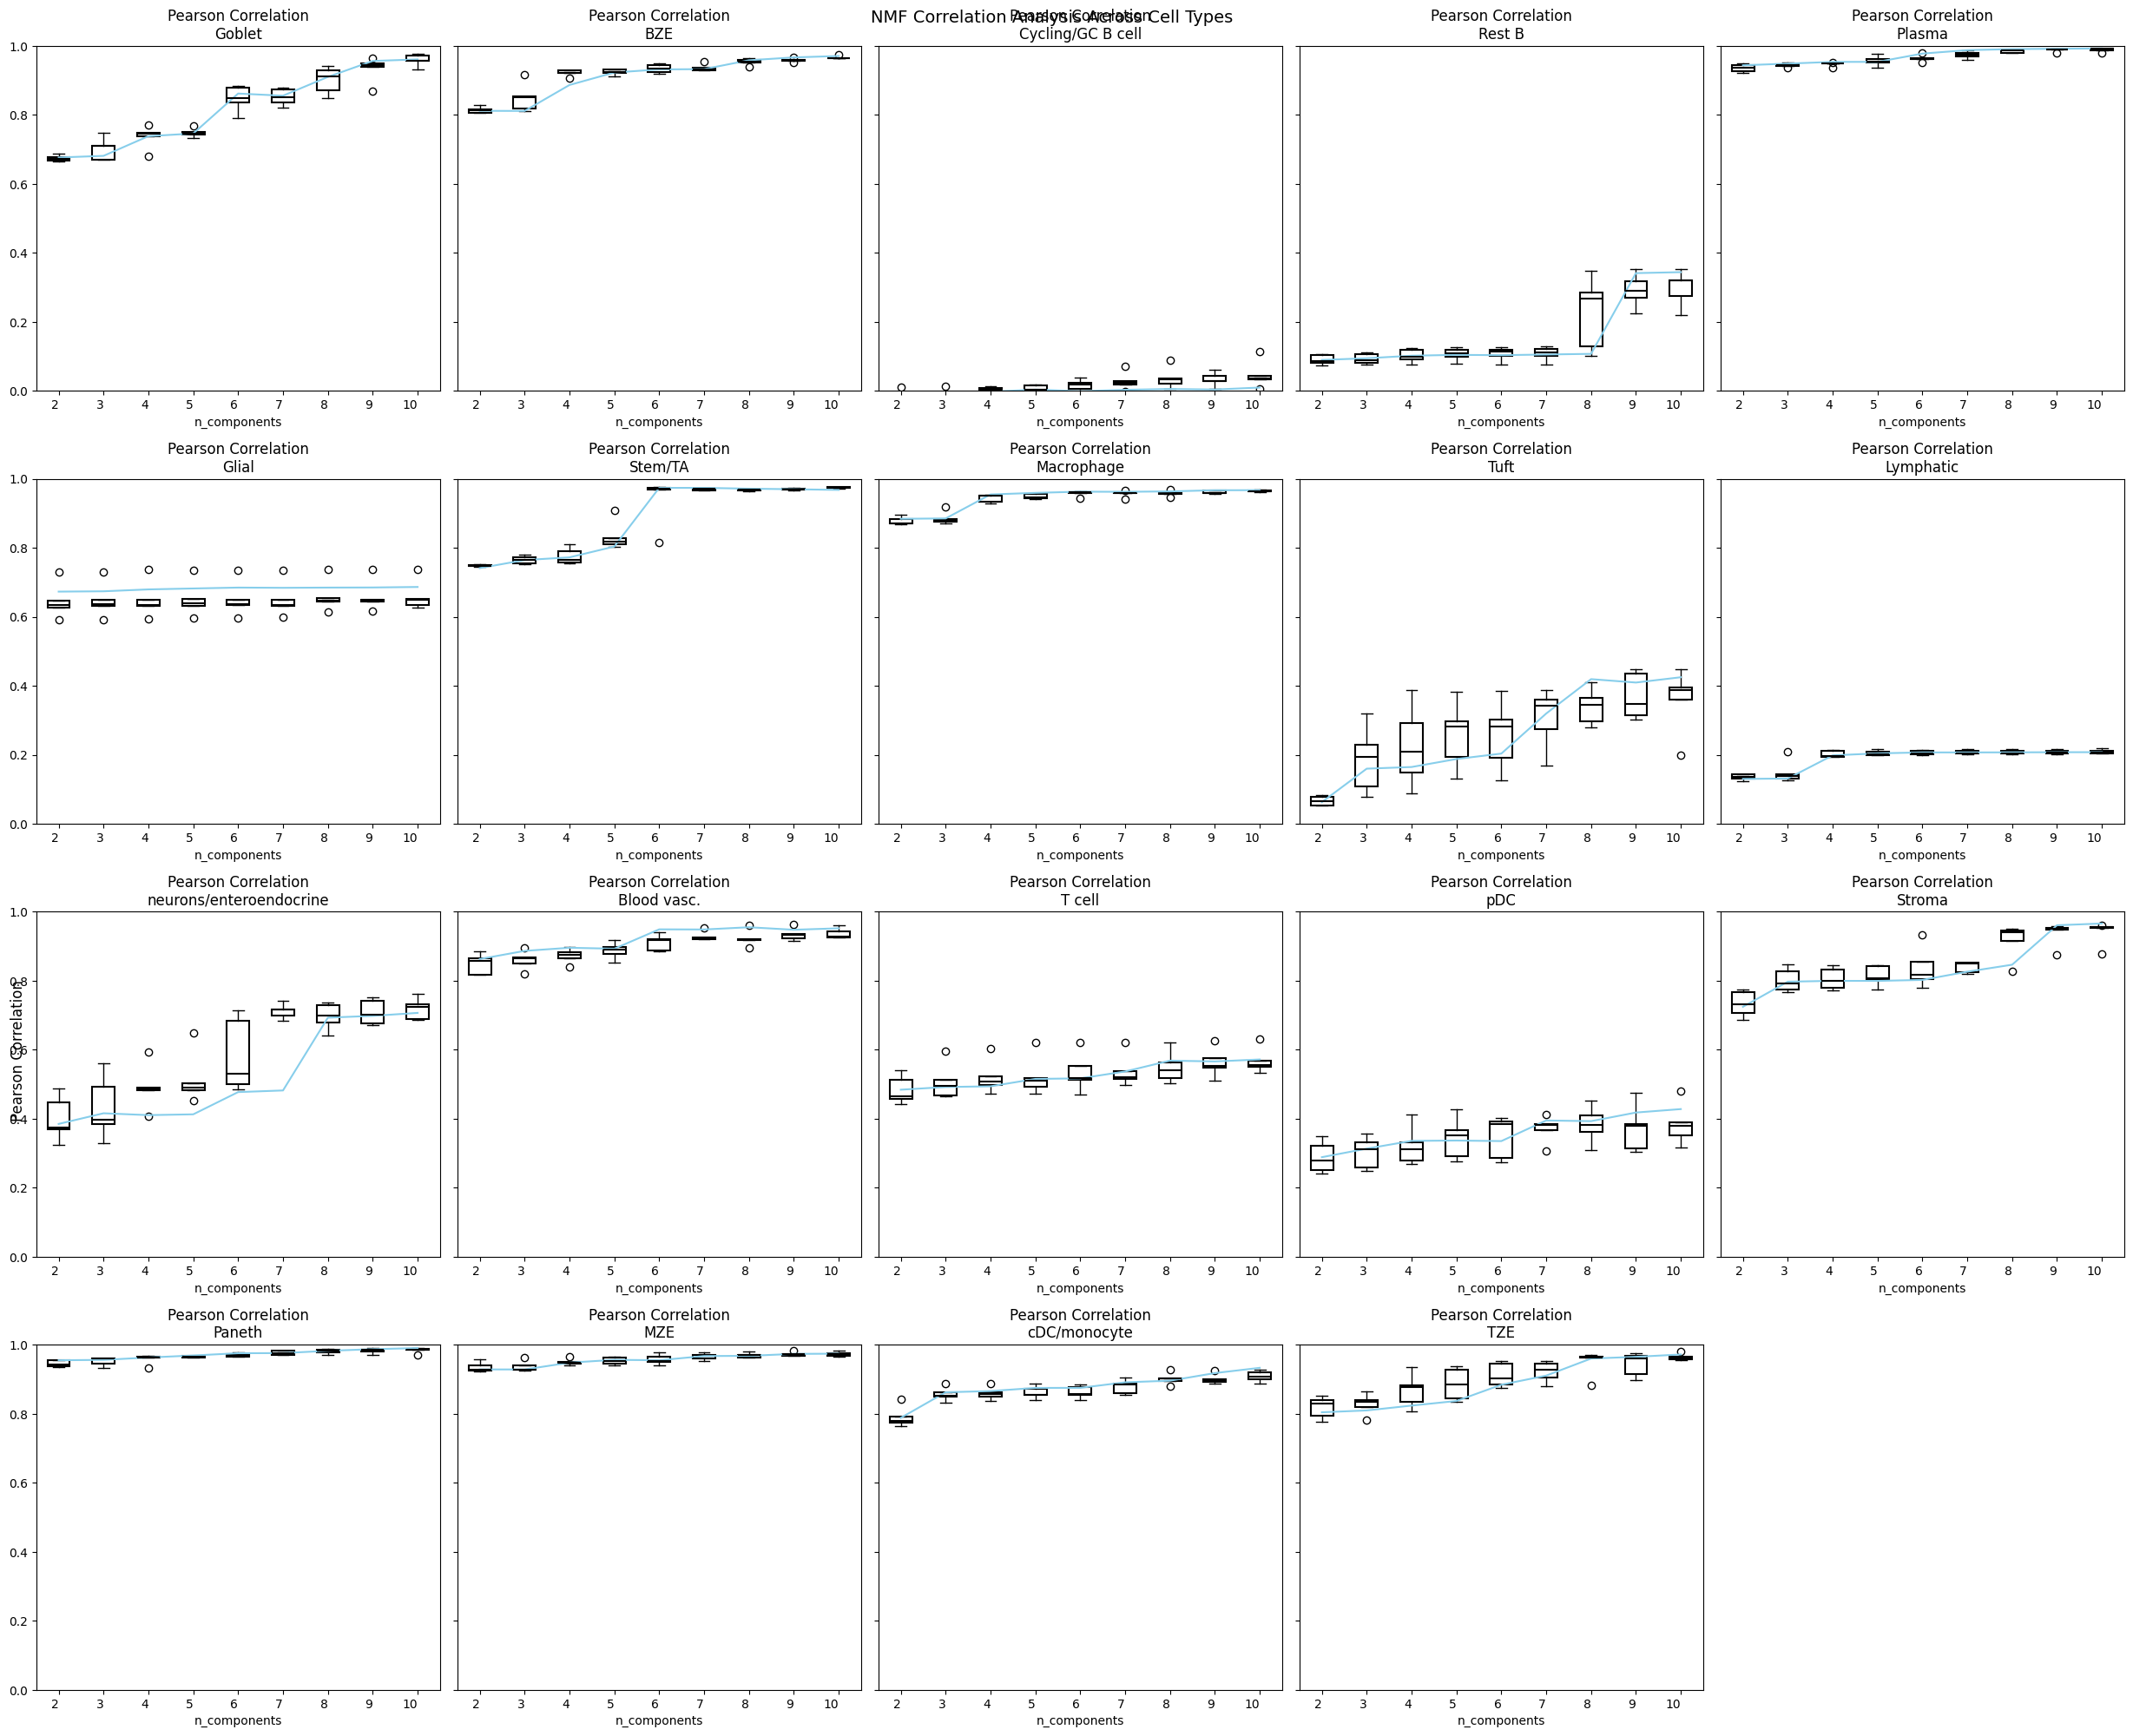

In [32]:
plot_bar_box_celltype_dict(pearson_correlation_transfer_results, n_components_range)

In [73]:
save_name = "./data/cosine_correlation_reconstruction_results_transformed.pkl"
pearson_correlation_reconstruction_results = {
    celltype: {
        "bar_values": nmf_reconstruction_correlation_curve(
            filter_by_obs_value(adata_sp, "celltype", celltype), 
            filter_by_obs_value(adata_sc, "celltype", celltype), 
            n_components_range,
            shared_genes
        ), 
        "box_values": np.array([nmf_reconstruction_correlation_curve(
            bootstrap_adata(filter_by_obs_value(adata_sp, "celltype", celltype)), 
            bootstrap_adata(filter_by_obs_value(adata_sc, "celltype", celltype)), 
            n_components_range,
            shared_genes) for _ in range(5)])
    }
    for celltype in tqdm(celltypes)
}

with open(save_name, "wb") as file:
    pickle.dump(pearson_correlation_reconstruction_results, file)

with open(save_name, "rb") as file:
    pearson_correlation_reconstruction_results = pickle.load(file)

100%|██████████| 19/19 [05:28<00:00, 17.26s/it]


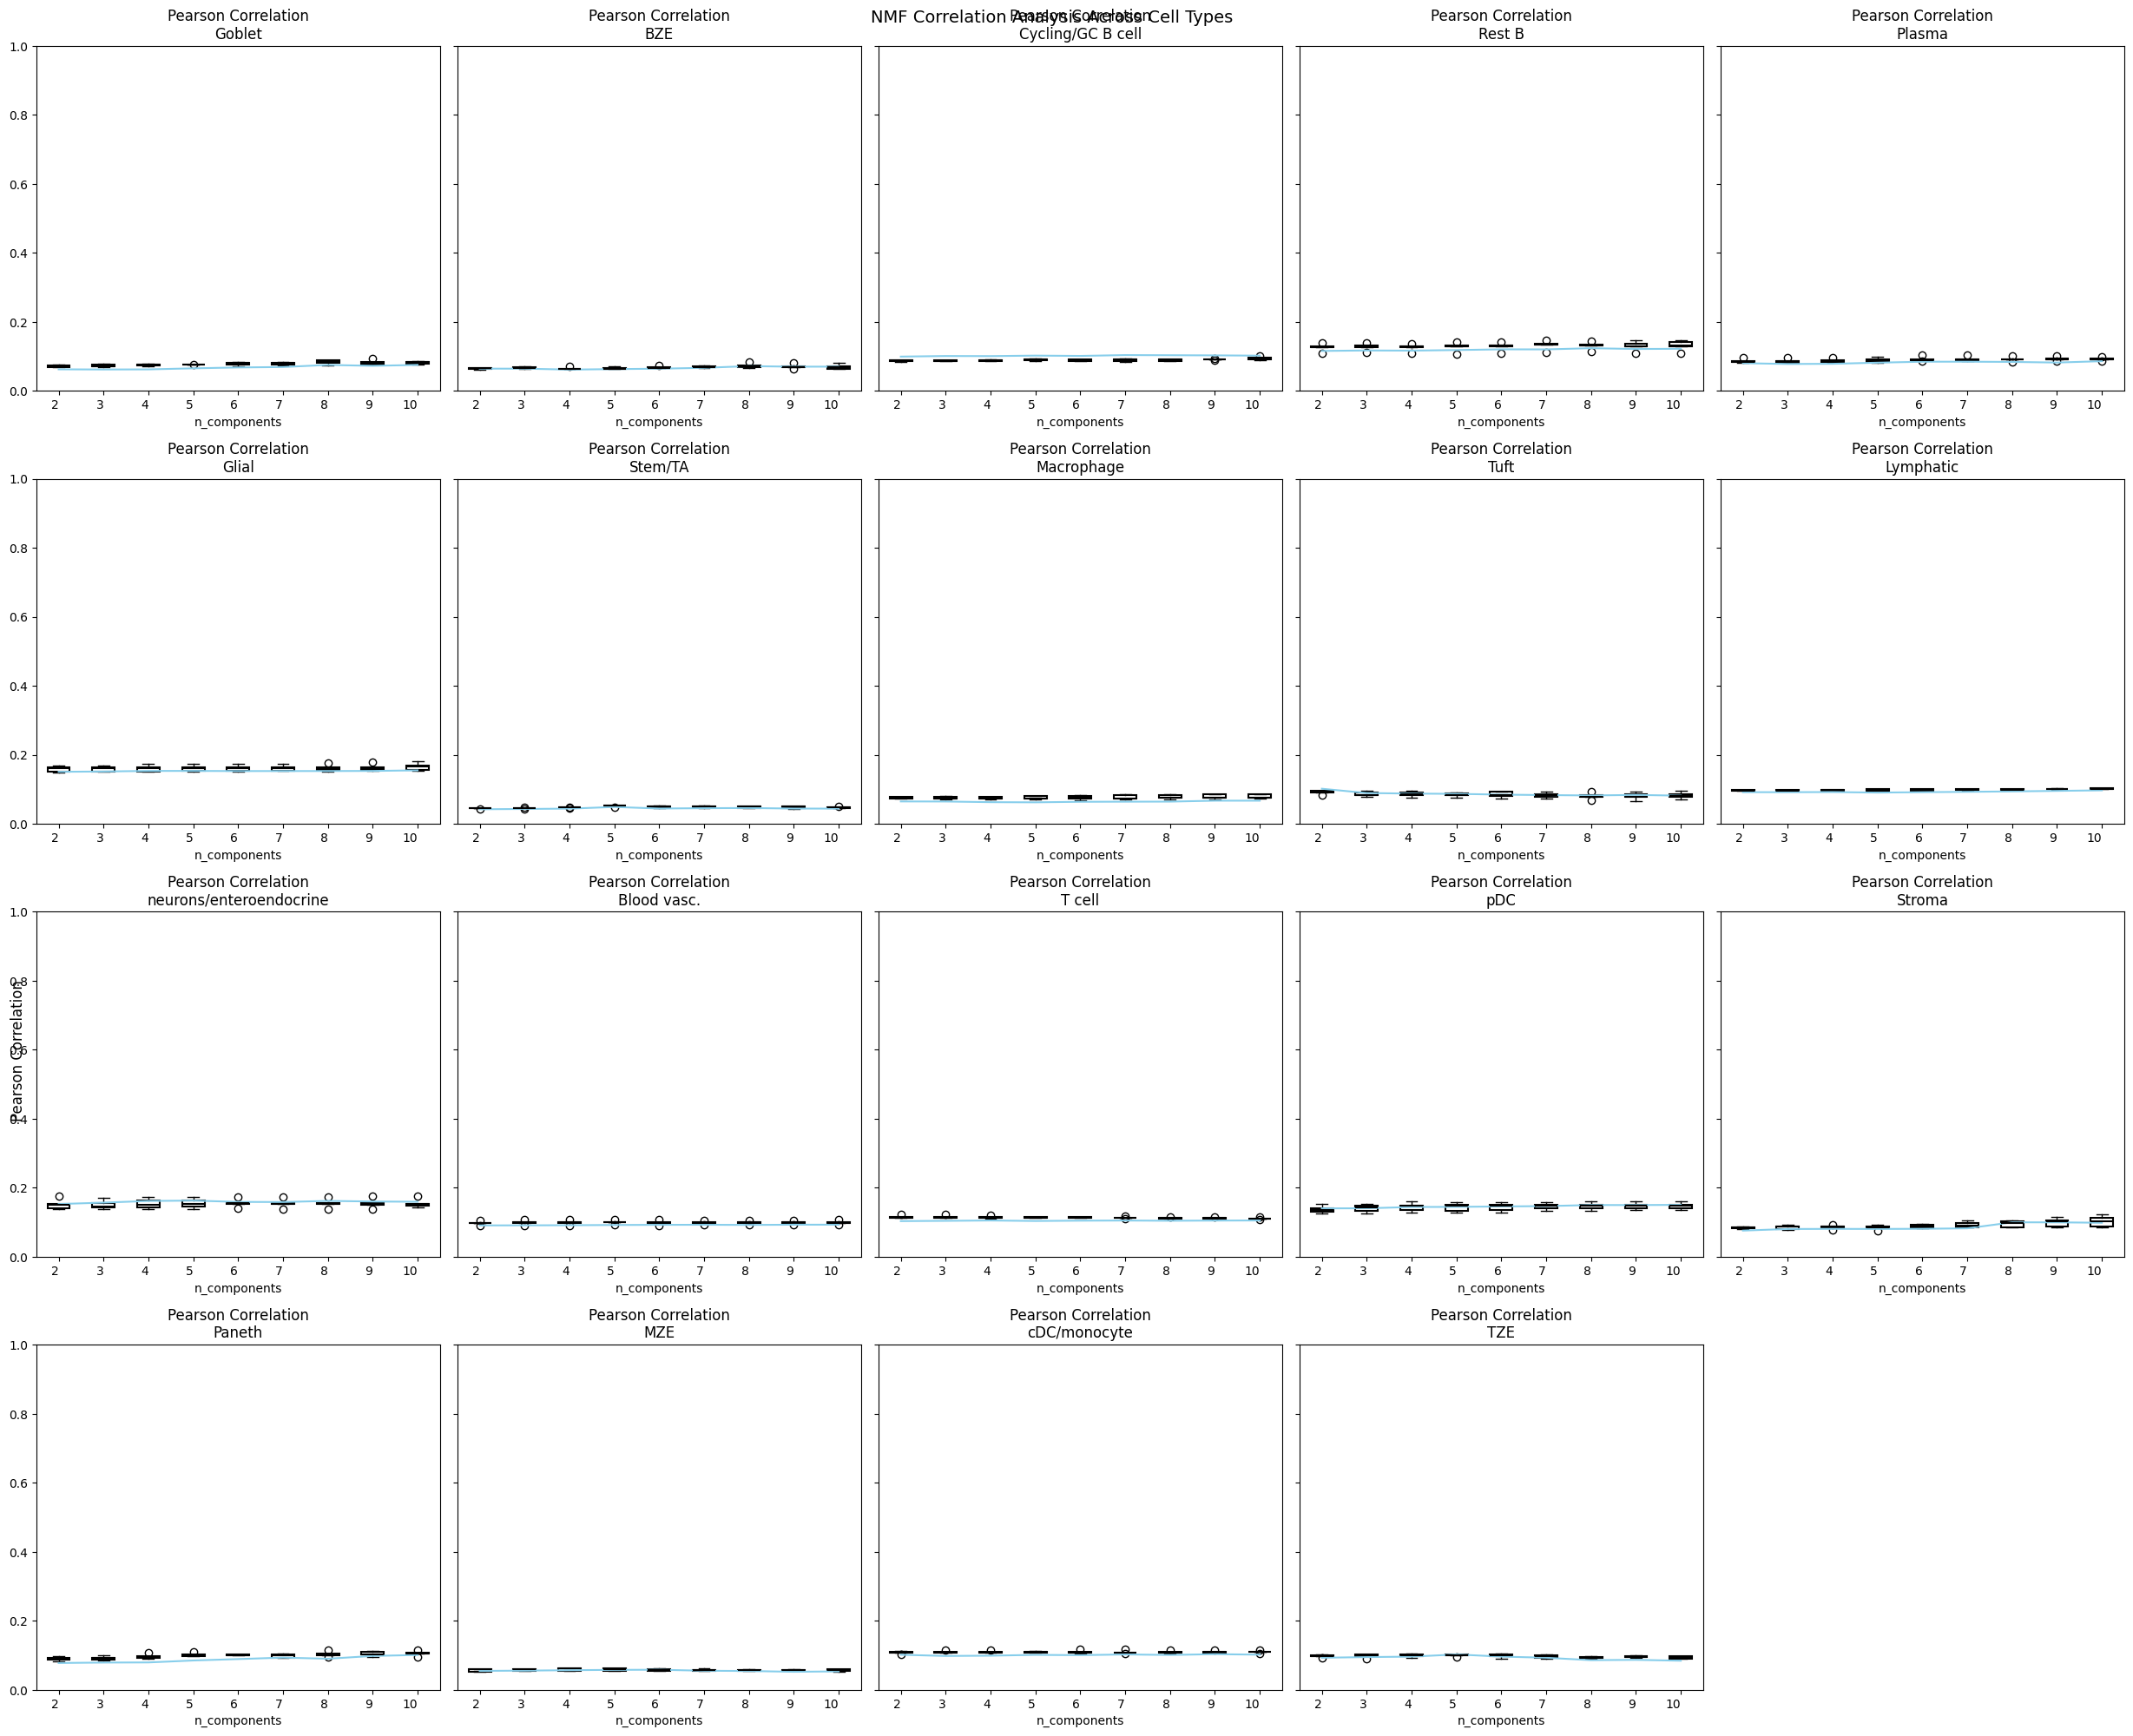

In [74]:
plot_bar_box_celltype_dict(pearson_correlation_reconstruction_results, n_components_range)

### Determine optimal n_components 

In [64]:
threshold = 0.7
filtered_celltypes = list(filter(lambda celltype: pearson_correlation_reconstruction_results[celltype]["box_values"].mean(axis=0).max() >= threshold, celltypes))
{celltype: n_components_range[np.argmax((lambda ndarray, threshold: (ndarray.mean(axis=0) >= threshold))(pearson_correlation_reconstruction_results[celltype]["box_values"], threshold))] for celltype in filtered_celltypes}

{'Stem/TA': 2}

## Explained Variance / MSE for reference data

In [63]:
@disk_cache(Path("data/cache/determine_n_components/"))
def non_negative_factorization_cached(*args, **kwargs):
    return non_negative_factorization(*args, **kwargs)

In [387]:
def compute_nmf_reconstruction(
    nmf_result: tuple[NDArray, NDArray, int]
) -> NDArray: 
    return nmf_result[0] @ nmf_result[1]

def nmf_metric_fn(
    func: Callable[[NDArray, NDArray], float], 
) -> Callable[[tuple[NDArray, tuple[NDArray, NDArray, int]]], float]:
    return lambda x: func(x[0], compute_nmf_reconstruction(x[1]))

def explained_variance(
    Y: NDArray, 
    Y_pred: NDArray
) -> float:
    return float(
        1 - (np.linalg.norm(Y - Y_pred, "fro") ** 2) / 
        np.linalg.norm(Y - Y_pred.mean(), "fro") ** 2
    )

In [396]:
celltypes = sorted(list(adata_sp.obs["celltype"].unique()))
n_components_range = list(range(2, 16))

nmf_results = return_multiindex_from_func(
    product(celltypes, n_components_range),
    lambda celltype, n_components: (
        adata_X_to_ndarray(filter_by_obs_value(adata_sp, "celltype", celltype).X),
        non_negative_factorization_cached(
            adata_X_to_ndarray(filter_by_obs_value(adata_sp, "celltype", celltype).X),
            n_components=n_components
        )
    ),
    ("celltype", "n_components")
)

In [397]:
metric_functions = {
    "MSE": nmf_metric_fn(lambda arr1, arr2: float(mean_squared_error(arr1, arr2))),
    "Explained Variance": nmf_metric_fn(explained_variance),
}
df = apply_funcs_to_Series(nmf_results, metric_functions)

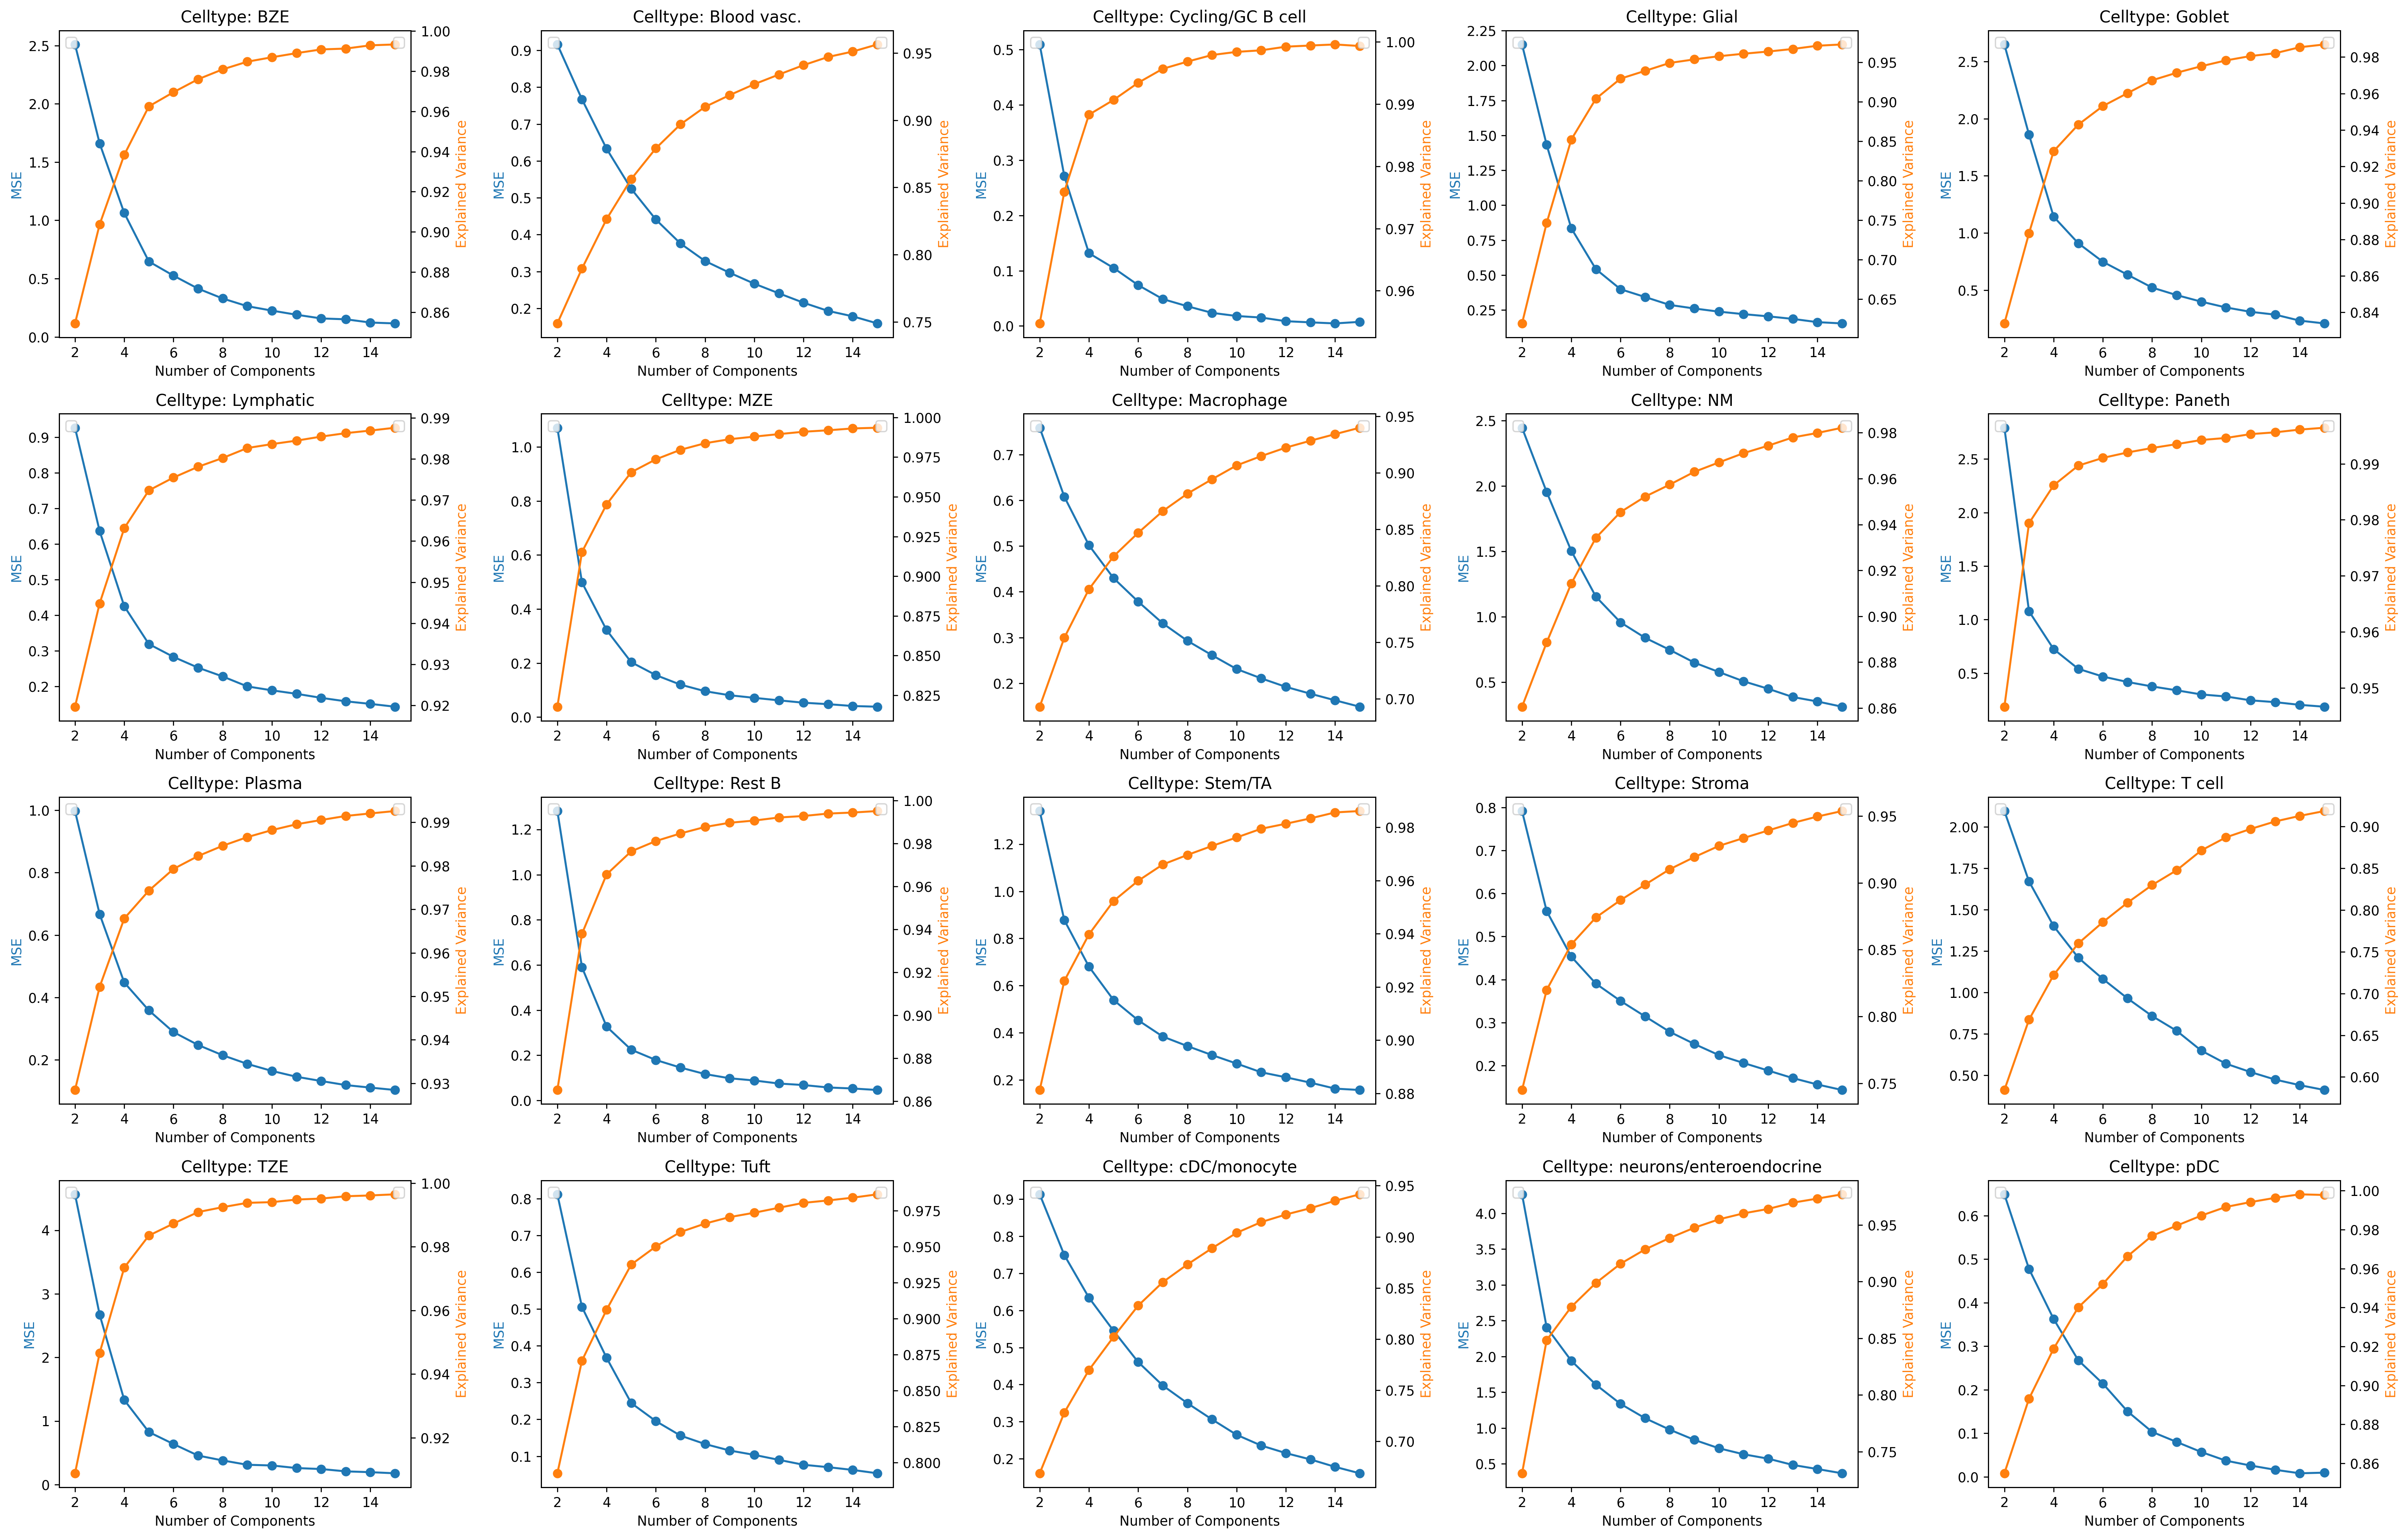

In [398]:
plot_celltype_metrics(df, n_cols=5, dpi=250)